In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import warnings
warnings.filterwarnings("ignore")

In [2]:
df = pd.read_csv('/Users/briankimanzi/Downloads/diabetes-2-1 (2) (1).csv')

# Data Understanding

In [3]:
df.sample(10) # generates a random sample data

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
183,5,73,60,0,0,26.8,0.268,27,0
324,2,112,75,32,0,35.7,0.148,21,0
447,0,95,80,45,92,36.5,0.330,26,0
627,0,132,78,0,0,32.4,0.393,21,0
41,7,133,84,0,0,40.2,0.696,37,0
650,1,91,54,25,100,25.2,0.234,23,0
191,9,123,70,44,94,33.1,0.374,40,0
363,4,146,78,0,0,38.5,0.520,67,1
182,1,0,74,20,23,27.7,0.299,21,0
400,4,95,64,0,0,32.0,0.161,31,1


In [4]:
df.head(20) # reading first 20 elements

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
5,5,116,74,0,0,25.6,0.201,30,0
6,3,78,50,32,88,31.0,0.248,26,1
7,10,115,0,0,0,35.3,0.134,29,0
8,2,197,70,45,543,30.5,0.158,53,1
9,8,125,96,0,0,0.0,0.232,54,1


In [5]:
df.tail(20) # reading last 20 elements

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
748,3,187,70,22,200,36.4,0.408,36,1
749,6,162,62,0,0,24.3,0.178,50,1
750,4,136,70,0,0,31.2,1.182,22,1
751,1,121,78,39,74,39.0,0.261,28,0
752,3,108,62,24,0,26.0,0.223,25,0
753,0,181,88,44,510,43.3,0.222,26,1
754,8,154,78,32,0,32.4,0.443,45,1
755,1,128,88,39,110,36.5,1.057,37,1
756,7,137,90,41,0,32.0,0.391,39,0
757,0,123,72,0,0,36.3,0.258,52,1


In [6]:
df.dtypes # checking the data types of the data

Pregnancies                    int64
Glucose                        int64
BloodPressure                  int64
SkinThickness                  int64
Insulin                        int64
BMI                          float64
DiabetesPedigreeFunction     float64
Age                            int64
Outcome                        int64
dtype: object

In [7]:
df.info() # print the concise summary of the data type

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Pregnancies                768 non-null    int64  
 1   Glucose                    768 non-null    int64  
 2   BloodPressure              768 non-null    int64  
 3   SkinThickness              768 non-null    int64  
 4   Insulin                    768 non-null    int64  
 5   BMI                        768 non-null    float64
 6   DiabetesPedigreeFunction   768 non-null    float64
 7   Age                        768 non-null    int64  
 8   Outcome                    768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [8]:
rows, columns = df.shape
print(f"Rows: {rows}, columns: {columns}")

Rows: 768, columns: 9


In [9]:
df.isna().sum() # checking the missing values

Pregnancies                  0
Glucose                      0
BloodPressure                0
SkinThickness                0
Insulin                      0
BMI                          0
DiabetesPedigreeFunction     0
Age                          0
Outcome                      0
dtype: int64

In [10]:
df.columns

Index(['Pregnancies ', 'Glucose ', 'BloodPressure ', 'SkinThickness ',
       'Insulin ', 'BMI  ', 'DiabetesPedigreeFunction ', 'Age ', 'Outcome'],
      dtype='object')

In [11]:
df.rename(columns={'DiabetesPedigreeFunction' :'DiabetesPedigreeFunc'}, inplace=True)

In [12]:
# calculating percentage of missing values
def missing_values_percentage(df: pd.DataFrame):
    """Function to check if there are 
    missing data on the dataset"""
    missing_percent = (df.isna().sum() / len(df)) * 100
    missing_df = pd.DataFrame({'Column':df.columns, 'Missing (%)': missing_percent})
    missing_df = missing_df[missing_df['Missing (%)'] > 0].sort_values(by='Missing (%)', ascending=False)

    return missing_df

In [13]:
missing_values_percentage(df) 

,Column,Missing (%)


In [14]:
df.columns = df.columns.str.lower() # changes the columns to lower cases

In [15]:
# checking duplicate on the dataset
df.duplicated().sum()

0

In [16]:
df.describe() # returns indepth analysis of the data

,pregnancies,glucose,bloodpressure,skinthickness,insulin,bmi,diabetespedigreefunction,age,outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


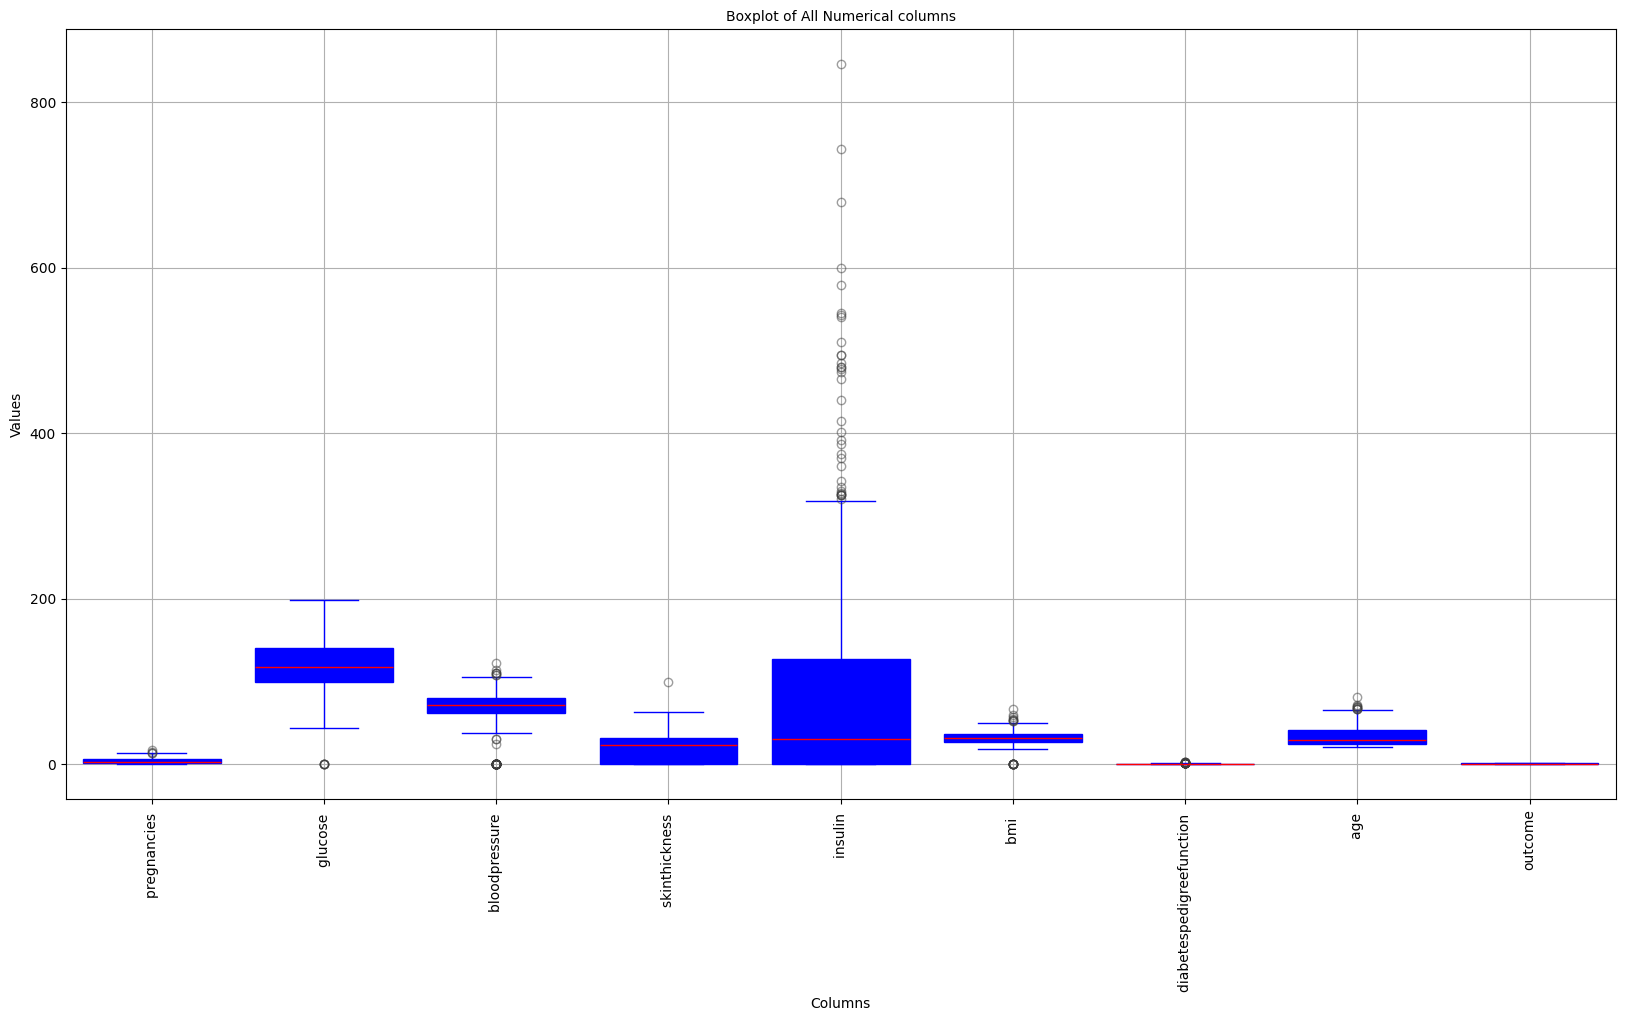

In [17]:
plt.subplots(figsize=(20, 10))
sns.boxplot(data=df, patch_artist=True, boxprops=dict(facecolor='lightblue', color='blue'),
             medianprops=dict(color='red'), whiskerprops=dict(color='blue'),
             capprops=dict(color='blue'), flierprops=dict(marker='o', color='blue', alpha=0.5))
plt.title("Boxplot of All Numerical columns", fontsize=10)
plt.xlabel("Columns", fontsize=10)
plt.ylabel("Values", fontsize=10)

plt.xticks(rotation=90, fontsize=10)

plt.grid(True)
plt.show()

In [18]:
# function to check outliners
def outliners(df):
    outliner_data = []
    for col in df.select_dtypes(include=['float64', 'int64']).columns:
        q1 = df[col].quantile(0.25)
        q3 = df[col].quantile(0.75)
        IQR = q3 - q1

        lower_bound = q1 - 1.5 * IQR
        upper_bound = q3 + 1.5 * IQR

        # counting Outliners
        outliners = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
        outliner_count = outliners.shape[0]
        outliners_perc = (outliner_count / df.shape[0]) * 100

        # Append details to the list
        outliner_data.append({
            'Columns': col,
            'outliners_count' : outliner_count,
            'outliners_percentage' : outliners_perc,
            'lower_bound': lower_bound,
            'upper_bound': upper_bound
        })

    outliner_df = pd.DataFrame(outliner_data)
    return outliner_df
    

In [19]:
outliners(df)

,Columns,outliners_count,outliners_percentage,lower_bound,upper_bound
0,pregnancies,4,0.520833,-6.500,13.500
1,glucose,5,0.651042,37.125,202.125
2,bloodpressure,45,5.859375,35.000,107.000
3,skinthickness,1,0.130208,-48.000,80.000
4,insulin,34,4.427083,-190.875,318.125
5,bmi,19,2.473958,13.350,50.550
6,diabetespedigreefunction,29,3.776042,-0.330,1.200
7,age,9,1.171875,-1.500,66.500
8,outcome,0,0.000000,-1.500,2.500


In [20]:
def remove_outliers(df: pd.DataFrame):
    # Create a copy of the dataframe to avoid modifying the original
    df_no_outliers = df.copy()

    # Loop through each column to calculate IQR and detect outliers
    for column in df.select_dtypes(include=['float64', 'int64']).columns:
        # Calculate Q1 (25th percentile) and Q3 (75th percentile)
        Q1 = df[column].quantile(0.25)
        Q3 = df[column].quantile(0.75)
        IQR = Q3 - Q1

        # Calculate the bounds for outliers
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR

        # Replace outliers with NaN
        df_no_outliers[column] = df[column].apply(
            lambda x: np.nan if (pd.notna(x) and (x < lower_bound or x > upper_bound)) else x
        )

    return df_no_outliers

In [21]:
cleaned_data = remove_outliers(df)
cleaned_data.sample(20)

,pregnancies,glucose,bloodpressure,skinthickness,insulin,bmi,diabetespedigreefunction,age,outcome
351,4.0,137.0,84.0,0.0,0.0,31.2,0.252,30.0,0
157,1.0,109.0,56.0,21.0,135.0,25.2,0.833,23.0,0
455,NaN,175.0,62.0,30.0,0.0,33.6,0.212,38.0,1
120,0.0,162.0,76.0,56.0,100.0,NaN,0.759,25.0,1
665,1.0,112.0,80.0,45.0,132.0,34.8,0.217,24.0,0
184,4.0,141.0,74.0,0.0,0.0,27.6,0.244,40.0,0
553,1.0,88.0,62.0,24.0,44.0,29.9,0.422,23.0,0
439,6.0,107.0,88.0,0.0,0.0,36.8,0.727,31.0,0
574,1.0,143.0,86.0,30.0,NaN,30.1,0.892,23.0,0
389,3.0,100.0,68.0,23.0,81.0,31.6,0.949,28.0,0


In [22]:
Rows, columns = cleaned_data.shape
print(f"Rows: {Rows} Columns: {columns}")

Rows: 768 Columns: 9


In [23]:
missing_values_percentage(cleaned_data)

,Column,Missing (%)
bloodpressure,bloodpressure,5.859375
insulin,insulin,4.427083
diabetespedigreefunction,diabetespedigreefunction,3.776042
bmi,bmi,2.473958
age,age,1.171875
glucose,glucose,0.651042
pregnancies,pregnancies,0.520833
skinthickness,skinthickness,0.130208


In [24]:
# loop to fill all the missing values
for column in cleaned_data.select_dtypes(include=['int64', 'float64']).columns:
    cleaned_data[column] = cleaned_data[column].fillna(cleaned_data[column].median())

In [25]:
missing_values_percentage(cleaned_data)

,Column,Missing (%)


# Data Preparation
<h2> Data Scaling on the values </h2>

In [26]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler
def scale_dataset(df: pd.DataFrame, target_column : str, scaling_type : str = 'standard') -> pd.DataFrame:
    """
    Scales: 
    Numerical columns on the dataFrame.
    parameters:
    df (pd.DataFrame): the input dataframe
    scaling_type (str) The type of scaling to apply, either standard or minmax

    Returns:
    pd.DataFrame: A dataframe with scaled numerical columns    
    """
    df_scaled = df.copy()
    # selecting numerical columns
    numerical_columns = df_scaled.select_dtypes(include=['int64', 'float64']).columns
    columns_to_scale = numerical_columns.difference([target_column])

    if scaling_type == 'standard':
        scaler = StandardScaler()
    elif scaling_type == 'minmax':
        scaler = MinMaxScaler()

    else:
        raise ValueError("Unsupported Scaling_type. Use standard or minmax")

    df_scaled[columns_to_scale] = scaler.fit_transform(df_scaled[columns_to_scale])

    return df_scaled


In [27]:
# Scaling the dataset
df_scaled = scale_dataset(cleaned_data, scaling_type='standard', target_column='outcome')
df_scaled.sample(10)

,pregnancies,glucose,bloodpressure,skinthickness,insulin,bmi,diabetespedigreefunction,age,outcome
413,-0.851320,0.701671,0.161892,0.099596,0.018261,-0.936403,-0.697675,-1.064466,0
448,-1.157270,-0.580445,-0.735818,1.055721,0.056544,0.218695,0.338370,-0.973953,1
315,-0.545371,-0.317447,-0.376734,0.099596,0.439371,0.296742,-0.457019,-0.611903,0
601,0.678427,-0.843443,-0.017650,-1.302720,-0.760155,-1.326639,-0.966884,-0.430878,0
524,-0.239421,0.109925,-1.274443,-1.302720,-0.760155,-0.093494,-1.125962,-0.792928,0
244,-0.545371,0.800295,0.341433,0.928238,1.715463,0.936729,-0.399914,-0.340365,0
739,-0.851320,-0.646195,0.161892,-1.302720,-0.760155,1.139651,-0.546755,0.836299,1
362,0.372477,-0.613320,-0.017650,1.055721,-0.760155,1.092823,-0.497808,2.918089,0
11,1.902225,1.523540,0.161892,-1.302720,-0.760155,0.905510,0.448500,0.112198,1
492,0.066528,-0.744819,-0.376734,1.119463,-0.760155,0.093819,-1.150435,0.021685,0


In [28]:
df_scaled.outcome.value_counts()

outcome
0    500
1    268
Name: count, dtype: int64

In [29]:
# checking for class imbalance
from imblearn.over_sampling import SMOTE
def balance_with_smote(df: pd.DataFrame, target_column: str):
    """
    Apply smote to Balance the dataset
    
    Parameters:
    df (pd.DataFrame): Input DataFrame (encoded and scaled)
    target_column (str): Name of the target column.

    Return:
    X_resampled (pd.Dataframe): Resampled feature set
    y_resampled (pd.series): Resampled target column
    
    """
    X = df.drop(columns=[outcome])
    Y = df[outcome]

    smote = SMOTE(random_state=142)
    X_resampled, y_resampled = smote.fit_resample(X, Y)

    # Convert back to dataframe
    X_resampled = pd.DataFrame(X_resampled, columns=X.columns)
    y_resampled = pd.Series(y_resampled, name=outcome)
    
    return X_resampled, y_resampled

In [ ]:
# balancing the dataset
# X_resampled, y_resampled = balance_with_smote(df = df_scaled, target_column='outcome')

<h2> Spliting the train and test sets </h2>

In [35]:
X = df_scaled.drop(columns='outcome')
y = df_scaled['outcome']

# splitting the dataet into train, test and validation
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

<h2> Model Building and evaluation </h2>

In [33]:
# model libraries

from sklearn.linear_model import LogisticRegression
from sklearn.multiclass import OneVsRestClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import LinearSVC
from xgboost import XGBClassifier

# model metrics libraries
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report

1. <h2> Baseline model: Logistic Regression</h2>

In [36]:
# Multiclass with OneVsRestClassifier
OvR_clr = OneVsRestClassifier(LinearSVC(random_state=42, dual=False, max_iter=5000))
OvR_clr.fit(X_train, y_train)
y_pred_ovr_clf = OvR_clr.predict(X_test)

In [38]:
# Model Evaluation for Logistic Regression
print("MultiClass with OnevsRest:")
print(f"Accuracy: {accuracy_score(y_test, y_pred_ovr_clf):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_ovr_clf, average='macro'):.4f}")
print(f"Recall: {recall_score(y_test, y_pred_ovr_clf, average='macro'):.4f}")
print(f"f1_score: {f1_score(y_test, y_pred_ovr_clf, average='macro'):.4f}")

MultiClass with OnevsRest:
Accuracy: 0.7240
Precision: 0.7006
Recall: 0.7018
f1_score: 0.7012


In [39]:
# Evaluation
print("Confusion Metrics")

print(confusion_matrix(y_test, y_pred_ovr_clf))
print("Classification Report:\n", classification_report(y_test, y_pred_ovr_clf))

Confusion Metrics
[[96 27]
 [26 43]]
Classification Report:
               precision    recall  f1-score   support

           0       0.79      0.78      0.78       123
           1       0.61      0.62      0.62        69

    accuracy                           0.72       192
   macro avg       0.70      0.70      0.70       192
weighted avg       0.72      0.72      0.72       192



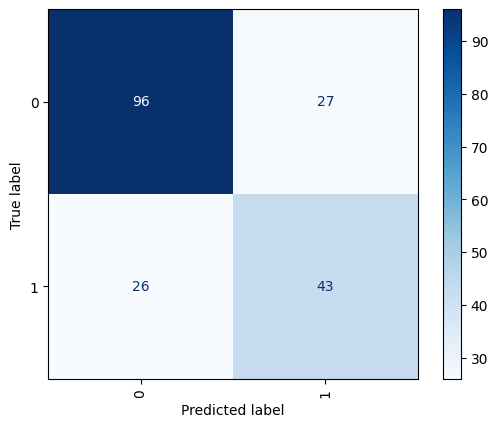

In [43]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
cm = confusion_matrix(y_test, y_pred_ovr_clf, labels=OvR_clr.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=OvR_clr.classes_)
disp.plot(cmap='Blues')
plt.xticks(rotation=90)
plt.show()

2. <h2> Decision Tress </h2>

In [44]:
# decision trees
from sklearn.tree import DecisionTreeClassifier
dtree = DecisionTreeClassifier()
dtree.fit(X_train, y_train)
y_pred_tree = dtree.predict(X_test)

In [51]:
print("MultiClass with Decision Tree Classifier:")
print(f"Accuracy: {accuracy_score(y_test, y_pred_tree):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_tree, average='macro'):.4f}")
print(f"Recall: {recall_score(y_test, y_pred_tree, average='macro'):.4f}")
print(f"f1_score: {f1_score(y_test, y_pred_tree, average='macro'):.4f}")

MultiClass with Decision Tree Classifier:
Accuracy: 0.6823
Precision: 0.6616
Recall: 0.6693
f1_score: 0.6638


In [46]:
# Evaluation
print("Confusion Metrics")

print(confusion_matrix(y_test, y_pred_tree))
print("Classification Report:\n", classification_report(y_test, y_pred_tree))

Confusion Metrics
[[88 35]
 [26 43]]
Classification Report:
               precision    recall  f1-score   support

           0       0.77      0.72      0.74       123
           1       0.55      0.62      0.59        69

    accuracy                           0.68       192
   macro avg       0.66      0.67      0.66       192
weighted avg       0.69      0.68      0.69       192



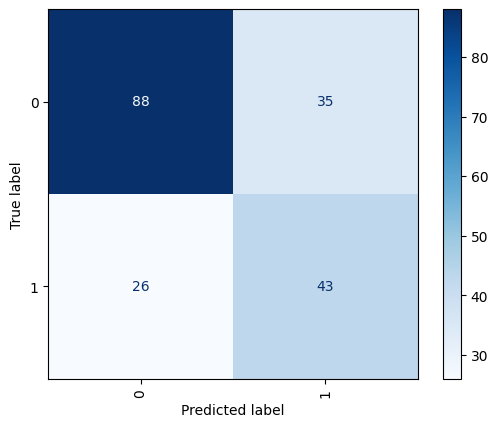

In [47]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
cm = confusion_matrix(y_test, y_pred_tree, labels=dtree.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=dtree.classes_)
disp.plot(cmap='Blues')
plt.xticks(rotation=90)
plt.show()

3. <h2> Random Forest </h2>

In [48]:
# random forest classifier
rf = RandomForestClassifier(random_state=142)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

In [52]:
print("MultiClass with Random Forest Classifier:")
print(f"Accuracy: {accuracy_score(y_test, y_pred_rf):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_rf, average='macro'):.4f}")
print(f"Recall: {recall_score(y_test, y_pred_rf, average='macro'):.4f}")
print(f"f1_score: {f1_score(y_test, y_pred_rf, average='macro'):.4f}")

MultiClass with Random Forest Classifier:
Accuracy: 0.7604
Precision: 0.7401
Recall: 0.7430
f1_score: 0.7415


In [53]:
# Evaluation
print("Confusion Metrics")

print(confusion_matrix(y_test, y_pred_rf))
print("Classification Report:\n", classification_report(y_test, y_pred_rf))

Confusion Metrics
[[99 24]
 [22 47]]
Classification Report:
               precision    recall  f1-score   support

           0       0.82      0.80      0.81       123
           1       0.66      0.68      0.67        69

    accuracy                           0.76       192
   macro avg       0.74      0.74      0.74       192
weighted avg       0.76      0.76      0.76       192



In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
cm = confusion_matrix(y_test, y_pred_rf, labels=rf.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=rf.classes_)
disp.plot(cmap='Blues')
plt.xticks(rotation=90)
plt.show()